# **Análisis de Rendimiento del Sistema Híbrido FarmCode Detector**
**Módulo de análisis y evaluación del orquestador híbrido para la detección y decodificación automática de códigos de barras en imágenes de cupones farmacéuticos.**

## **1. Configuración del Entorno**

### **1.1 Importación de Librerías**


In [147]:
# ===== CONFIGURACIÓN INICIAL =====
import sys
import importlib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Añadir rutas necesarias
sys.path.append('../')
sys.path.append('core/')

print("🚀 INICIANDO ANÁLISIS COMPARATIVO DEL SISTEMA HÍBRIDO")
print("=" * 70)


🚀 INICIANDO ANÁLISIS COMPARATIVO DEL SISTEMA HÍBRIDO


In [148]:
# ===== LIBRERÍAS PRINCIPALES =====
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import cv2
import json
import time
from datetime import datetime

# Importar el orquestador híbrido
from farmcode_detector.core.orchestrator import Orchestrator

# Configuración visual profesional
plt.rcParams.update({
    'figure.figsize': (18, 12),
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 150,
    'axes.linewidth': 2,
    'grid.alpha': 0.4,
    'axes.grid': True
})

print("✅ Librerías cargadas correctamente")
print("✅ Configuración visual aplicada")


✅ Librerías cargadas correctamente
✅ Configuración visual aplicada


In [149]:
# ===== VERIFICACIÓN DEL SISTEMA =====
def verificar_sistema_hibrido():
    """Verifica que todos los componentes estén disponibles"""
    try:
        # Verificar orquestador
        orchestrator_test = Orchestrator
        
        # Verificar rutas necesarias
        test_dir = Path("dataset/yolo_format/images/test")
        ground_truth_dir = Path("data/ground_truth")
        
        print("VERIFICACIÓN DEL SISTEMA HÍBRIDO")
        print("=" * 50)
        print(f"✅ Orquestador disponible: {orchestrator_test is not None}")
        print(f"✅ Dataset test: {'Disponible' if test_dir.exists() else 'No encontrado'}")
        print(f"✅ Ground truth: {'Disponible' if ground_truth_dir.exists() else 'No encontrado'}")
        print(f"✅ Imágenes test: {len(list(test_dir.glob('*.jpg')))} encontradas")
        
        return True
        
    except Exception as e:
        print(f"❌ Error en verificación: {e}")
        return False

# Ejecutar verificación
sistema_ok = verificar_sistema_hibrido()
if not sistema_ok:
    print("⚠️ Revisar configuración antes de continuar")


VERIFICACIÓN DEL SISTEMA HÍBRIDO
✅ Orquestador disponible: True
✅ Dataset test: Disponible
✅ Ground truth: Disponible
✅ Imágenes test: 12 encontradas


## **2. Configuración del Dataset y Sistema**

### **2.1 Información del Dataset y Componentes del Sistema**


In [150]:
# ===== CONFIGURACIÓN DEL DATASET Y SISTEMA =====
# Información del sistema híbrido
sistema_info = {
    "Nombre": "FarmCode Detector Híbrido",
    "Componentes": "YOLO + Gradientes + Orquestador",
    "Modelo YOLO": "yolov10_train7/weights/best.pt",
    "Detector": "Gradientes direccionales",
    "Corrección": "GridPositionCorrector",
    "Dataset": "yolo_format",
    "Imágenes test": len(list(Path("dataset/yolo_format/images/test").glob("*.jpg")))
}

print("CONFIGURACIÓN DEL SISTEMA HÍBRIDO:")
for key, value in sistema_info.items():
    print(f"   {key:.<30} {value}")

# Configurar rutas
yolo_model_path = "runs/detect/yolov10_train7/weights/best.pt"
test_dir = Path("dataset/yolo_format/images/test")
ground_truth_dir = Path("data/ground_truth")
output_dir = Path("data/predictions/farmcode")

# Crear directorio de salida si no existe
output_dir.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Directorio de salida: {output_dir}")


CONFIGURACIÓN DEL SISTEMA HÍBRIDO:
   Nombre........................ FarmCode Detector Híbrido
   Componentes................... YOLO + Gradientes + Orquestador
   Modelo YOLO................... yolov10_train7/weights/best.pt
   Detector...................... Gradientes direccionales
   Corrección.................... GridPositionCorrector
   Dataset....................... yolo_format
   Imágenes test................. 12

📁 Directorio de salida: data\predictions\farmcode


## **3. Procesamiento con Sistema Híbrido**

### **3.1 Ejecución del Orquestador Híbrido**


In [151]:
# ===== INICIALIZACIÓN Y PROCESAMIENTO =====
def procesar_con_sistema_hibrido():
    """Procesa todas las imágenes con el sistema híbrido y guarda resultados"""
    
    print("🔄 PROCESANDO CON SISTEMA HÍBRIDO")
    print("-" * 60)
    
    # Inicializar orquestador
    try:
        orchestrator = Orchestrator(yolo_model_path=yolo_model_path, debug=True)
        print("✅ Orquestador inicializado correctamente")
    except Exception as e:
        print(f"❌ Error inicializando orquestador: {e}")
        return []
    
    resultados_hibrido = []
    imagenes = list(test_dir.glob("*.jpg"))
    
    for i, imagen_path in enumerate(imagenes, 1):
        print(f"\n[{i:2d}/{len(imagenes)}] Procesando: {imagen_path.name}")
        
        try:
            start_time = time.time()
            
            # Procesar imagen
            resultado, error = orchestrator.process_imge(str(imagen_path))
            
            processing_time = time.time() - start_time
            
            if not error and resultado:
                # Completar información del resultado
                resultado['processing_time'] = processing_time
                resultado['image_name'] = imagen_path.name
                resultado['timestamp'] = datetime.now().isoformat()
                
                # Guardar resultado completo
                guardar_resultado_completo(imagen_path.name, resultado)
                
                # Guardar resultado simple para comparación
                guardar_resultado_simple(imagen_path.name, resultado)
                
                resultados_hibrido.append(resultado)
                
                # Mostrar métricas
                print(f"    ✅ Códigos: {resultado['valid_codes']}/{resultado['max_codes']}")
                print(f"    📊 Tasa éxito: {resultado['success_rate']*100:.1f}%")
                print(f"    ⏱️ Tiempo: {processing_time:.2f}s")
                print(f"    🔧 Header: {'Detectado' if resultado['header_detected'] else 'No detectado'}")
                print(f"    📐 Layout: {resultado['grid_layout'][0]}x{resultado['grid_layout'][1]}")
                
            else:
                print(f"    ❌ Error: {error}")
                
        except Exception as e:
            print(f"    💥 Excepción: {str(e)}")
    
    print(f"\n✅ Procesamiento completado: {len(resultados_hibrido)} imágenes exitosas")
    return resultados_hibrido

def guardar_resultado_completo(image_name, resultado):
    """Guarda el resultado completo en JSON"""
    filename = image_name.replace('.jpg', '_complete.json')
    filepath = output_dir / filename
    
    with open(filepath, 'w') as f:
        json.dump(resultado, f, indent=2, ensure_ascii=False)
    
    print(f"    💾 JSON completo: {filepath}")

def guardar_resultado_simple(image_name, resultado):
    """Guarda solo los códigos en orden posicional para comparación"""
    filename = image_name.replace('.jpg', '_simple.json')
    filepath = output_dir / filename
    
    # Extraer códigos en orden posicional
    max_codes = resultado['max_codes']
    codes_simple = []
    
    for pos in range(1, max_codes + 1):
        if pos in resultado['decoded_results']:
            code = resultado['decoded_results'][pos].get('code', 'Código no encontrado')
            if code in ['No detectado', '', None]:
                code = 'Código no encontrado'
            codes_simple.append(code)
        else:
            codes_simple.append('Código no encontrado')
    
    with open(filepath, 'w') as f:
        json.dump(codes_simple, f, indent=2, ensure_ascii=False)
    
    print(f"    💾 JSON simple: {filepath}")

# Ejecutar procesamiento
resultados_sistema_hibrido = procesar_con_sistema_hibrido()


🔄 PROCESANDO CON SISTEMA HÍBRIDO
------------------------------------------------------------


BarcodeDetector inicializando con: runs/detect/yolov10_train7/weights/best.pt
✅ Preprocessor inyectado: True
✅ Orquestador simple inicializado
✅ Orquestador inicializado correctamente

[ 1/12] Procesando: codigos10.jpg
🔍 PROCESANDO: codigos10.jpg
   Dimensiones: (2048, 1152, 3)
   Header detectado: True
   Grid config: {'rows': 6, 'cols': 4, 'max_codes': 24, 'layout_type': 'with_header'}
PASO 3: Recortando zona de códigos...

0: 640x384 25 codes, 1 header, 1 barcode, 627.2ms
Speed: 11.0ms preprocess, 627.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 384)
Recorte original YOLO: bbox=(97, 653, 1110, 1709)
Recorte (con_header): bbox=(94, 650, 1113, 1717)
Razón: Header detectado - márgenes mínimos
Márgenes: L=3, R=3, T=3, B=8
   Región barcode detectada exitosamente
   Crop bbox: [94, 650, 1113, 1717]
  Ejecutando detección conservadora...
  Códigos detectados: 29
   Rectángulos por gradientes: 29
🔧 MERGE CON MÚLTIPLES RONDAS: 29 rectángulos
  Agrupados en 6 filas
  Fila 

### **3.2 Generación de DataFrame Resumen**


In [152]:
import json
import numpy as np
from datetime import datetime

def numpy_serializable(obj):
    """Convierte arrays numpy a listas para serialización JSON"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, dict):
        return {key: numpy_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [numpy_serializable(item) for item in obj]
    else:
        return obj

def guardar_resultado_completo(image_name, resultado):
    """Guarda el resultado completo en JSON con manejo seguro"""
    filename = image_name.replace('.jpg', '_complete.json')
    filepath = output_dir / filename
    
    try:
        # Limpiar el resultado para evitar problemas de serialización
        resultado_limpio = resultado.copy()
        
        # Convertir barcode_region numpy array a lista si existe
        if 'barcode_region' in resultado_limpio:
            if isinstance(resultado_limpio['barcode_region'], np.ndarray):
                resultado_limpio['barcode_region'] = resultado_limpio['barcode_region'].tolist()
        
        # Aplicar conversión recursiva para otros arrays numpy
        resultado_serializable = numpy_serializable(resultado_limpio)
        
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(resultado_serializable, f, indent=2, ensure_ascii=False)
        
        print(f"    💾 JSON completo guardado: {filepath}")
        
    except Exception as e:
        print(f"    ❌ Error guardando JSON completo: {e}")

def guardar_resultado_simple(image_name, resultado):
    """Guarda solo los códigos en orden posicional para comparación"""
    filename = image_name.replace('.jpg', '_simple.json')
    filepath = output_dir / filename
    
    try:
        # Extraer códigos en orden posicional
        max_codes = resultado['max_codes']
        codes_simple = []
        
        for pos in range(1, max_codes + 1):
            if pos in resultado['decoded_results']:
                code = resultado['decoded_results'][pos].get('code', 'Código no encontrado')
                # Normalizar códigos vacíos o no detectados
                if code in ['No detectado', '', None, 'None']:
                    code = 'Código no encontrado'
            else:
                code = 'Código no encontrado'
            
            codes_simple.append(code)
        
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(codes_simple, f, indent=2, ensure_ascii=False)
        
        print(f"    💾 JSON simple guardado: {filepath}")
        
    except Exception as e:
        print(f"    ❌ Error guardando JSON simple: {e}")


In [153]:
# ===== PROCESAMIENTO CON MANEJO DE ERRORES ROBUSTO =====
def procesar_con_sistema_hibrido():
    """Procesa todas las imágenes con el sistema híbrido y guarda resultados"""
    
    print("🔄 PROCESANDO CON SISTEMA HÍBRIDO")
    print("-" * 60)
    
    # Verificar directorio de salida
    output_dir.mkdir(exist_ok=True)
    
    # Inicializar orquestador
    try:
        orchestrator = Orchestrator(yolo_model_path=yolo_model_path, debug=True)
        print("✅ Orquestador inicializado correctamente")
    except Exception as e:
        print(f"❌ Error inicializando orquestador: {e}")
        return []
    
    resultados_hibrido = []
    imagenes = list(test_dir.glob("*.jpg"))
    
    print(f"📁 Encontradas {len(imagenes)} imágenes para procesar")
    
    for i, imagen_path in enumerate(imagenes, 1):
        print(f"\n[{i:2d}/{len(imagenes)}] Procesando: {imagen_path.name}")
        
        try:
            start_time = time.time()
            
            # Procesar imagen
            resultado, error = orchestrator.process_image(str(imagen_path))
            
            processing_time = time.time() - start_time
            
            if not error and resultado:
                # Completar información del resultado
                resultado['processing_time'] = processing_time
                resultado['image_name'] = imagen_path.name
                resultado['timestamp'] = datetime.now().isoformat()
                
                # Guardar archivos JSON
                guardar_resultado_completo(imagen_path.name, resultado)
                guardar_resultado_simple(imagen_path.name, resultado)
                
                resultados_hibrido.append(resultado)
                
                # Mostrar métricas
                print(f"    ✅ Códigos: {resultado['valid_codes']}/{resultado['max_codes']}")
                print(f"    📊 Tasa éxito: {resultado['success_rate']*100:.1f}%")
                print(f"    ⏱️ Tiempo: {processing_time:.2f}s")
                print(f"    🔧 Header: {'Detectado' if resultado['header_detected'] else 'No detectado'}")
                print(f"    📐 Layout: {resultado['grid_layout'][0]}x{resultado['grid_layout'][1]}")
                
            else:
                print(f"    ❌ Error en procesamiento: {error}")
                # Crear archivo de error para referencia
                error_file = output_dir / f"{imagen_path.stem}_error.txt"
                with open(error_file, 'w') as f:
                    f.write(f"Error: {error}\nTimestamp: {datetime.now().isoformat()}")
                
        except Exception as e:
            print(f"    💥 Excepción durante procesamiento: {str(e)}")
            # Registrar excepción
            error_file = output_dir / f"{imagen_path.stem}_exception.txt"
            with open(error_file, 'w') as f:
                f.write(f"Exception: {str(e)}\nTimestamp: {datetime.now().isoformat()}")
    
    print(f"\n✅ Procesamiento completado: {len(resultados_hibrido)} imágenes exitosas de {len(imagenes)} totales")
    
    # Verificar archivos generados
    json_files = list(output_dir.glob("*_simple.json"))
    print(f"📄 Archivos JSON simple generados: {len(json_files)}")
    
    return resultados_hibrido

# Ejecutar procesamiento
resultados_sistema_hibrido = procesar_con_sistema_hibrido()


🔄 PROCESANDO CON SISTEMA HÍBRIDO
------------------------------------------------------------
BarcodeDetector inicializando con: runs/detect/yolov10_train7/weights/best.pt
✅ Preprocessor inyectado: True
✅ Orquestador simple inicializado
✅ Orquestador inicializado correctamente
📁 Encontradas 12 imágenes para procesar

[ 1/12] Procesando: codigos10.jpg
🔍 PROCESANDO: codigos10.jpg
   Dimensiones: (2048, 1152, 3)
   Header detectado: True
   Grid config: {'rows': 6, 'cols': 4, 'max_codes': 24, 'layout_type': 'with_header'}
PASO 3: Recortando zona de códigos...

0: 640x384 25 codes, 1 header, 1 barcode, 794.5ms
Speed: 22.9ms preprocess, 794.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 384)
Recorte original YOLO: bbox=(97, 653, 1110, 1709)
Recorte (con_header): bbox=(94, 650, 1113, 1717)
Razón: Header detectado - márgenes mínimos
Márgenes: L=3, R=3, T=3, B=8
   Región barcode detectada exitosamente
   Crop bbox: [94, 650, 1113, 1717]
  Ejecutando detección conservadora...


In [154]:
# ===== GENERAR DATAFRAME RESUMEN =====
def crear_dataframe_resumen(resultados):
    """Crea DataFrame resumen con métricas del sistema híbrido"""
    
    if not resultados:
        print("⚠️ No hay resultados para crear resumen")
        return pd.DataFrame()
    
    data = []
    for resultado in resultados:
        data.append({
            'image_name': resultado['image_name'],
            'valid_codes': resultado['valid_codes'],
            'max_codes': resultado['max_codes'],
            'failed_codes': resultado['max_codes'] - resultado['valid_codes'],
            'success_rate': resultado['success_rate'],
            'processing_time': resultado['processing_time'],
            'header_detected': resultado['header_detected'],
            'grid_layout': f"{resultado['grid_layout'][0]}x{resultado['grid_layout'][1]}",
            'timestamp': resultado['timestamp']
        })
    
    df = pd.DataFrame(data)
    
    print("📊 RESUMEN DEL PROCESAMIENTO:")
    print(f"   Imágenes procesadas: {len(df)}")
    print(f"   Accuracy promedio: {df['success_rate'].mean()*100:.1f}%")
    print(f"   Códigos promedio: {df['valid_codes'].mean():.1f}")
    print(f"   Tiempo promedio: {df['processing_time'].mean():.2f}s")
    
    return df

# Generar resumen
df_resumen_hibrido = crear_dataframe_resumen(resultados_sistema_hibrido)

if not df_resumen_hibrido.empty:
    # Mostrar tabla resumen
    print("\nTabla 3.1: Resumen de Rendimiento del Sistema Híbrido")
    display(df_resumen_hibrido[['image_name', 'valid_codes', 'max_codes', 'success_rate', 'processing_time']].style
            .background_gradient(cmap='Greens', subset=['success_rate'])
            .format({
                'success_rate': '{:.1%}',
                'processing_time': '{:.2f}s'
            })
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]}
            ]))


📊 RESUMEN DEL PROCESAMIENTO:
   Imágenes procesadas: 12
   Accuracy promedio: 79.0%
   Códigos promedio: 20.0
   Tiempo promedio: 6.84s

Tabla 3.1: Resumen de Rendimiento del Sistema Híbrido


,image_name,valid_codes,max_codes,success_rate,processing_time
0,codigos10.jpg,24,24,100.0%,7.48s
1,codigos11.jpg,24,26,92.3%,6.22s
2,codigos12.jpg,23,24,95.8%,5.11s
3,codigos14.jpg,22,24,91.7%,4.83s
4,codigos15.jpg,25,26,96.2%,4.49s
5,codigos16.jpg,23,26,88.5%,9.25s
6,codigos17.jpg,15,26,57.7%,10.01s
7,codigos18.jpg,20,26,76.9%,12.31s
8,codigos23.jpg,24,26,92.3%,8.72s
9,codigos24.jpg,5,26,19.2%,4.51s


## **4. Comparación con Ground Truth**

### **4.1 Evaluación con Correspondencia Posicional Exacta**


In [155]:
# ===== COMPARACIÓN CON GROUND TRUTH =====
def comparar_con_ground_truth_hibrido():
    """Compara resultados del sistema híbrido con ground truth"""
    
    print("🔍 COMPARACIÓN CON GROUND TRUTH (CORRESPONDENCIA POSICIONAL)")
    print("=" * 80)
    
    comparison_results = []
    
    for i, imagen_name in enumerate(df_resumen_hibrido['image_name'], 1):
        print(f"\n[{i:2d}/{len(df_resumen_hibrido)}] {imagen_name.replace('.jpg', '').upper()}")
        print("-" * 60)
        
        try:
            # Cargar ground truth
            gt_path = ground_truth_dir / f"{imagen_name.replace('.jpg', '')}_simple.json"
            if not gt_path.exists():
                print(f"    ⚠️ Ground truth no encontrado: {gt_path}")
                continue
            
            with open(gt_path, 'r') as f:
                ground_truth = json.load(f)
            
            # Cargar resultado del sistema híbrido
            result_path = output_dir / f"{imagen_name.replace('.jpg', '')}_simple.json"
            if not result_path.exists():
                print(f"    ⚠️ Resultado no encontrado: {result_path}")
                continue
            
            with open(result_path, 'r') as f:
                hibrido_codes = json.load(f)
            
            # Comparar posición por posición
            matches = 0
            comparisons = []
            
            min_length = min(len(ground_truth), len(hibrido_codes))
            
            for pos in range(min_length):
                match = ground_truth[pos] == hibrido_codes[pos]
                if match:
                    matches += 1
                
                comparisons.append({
                    'position': pos + 1,
                    'ground_truth': ground_truth[pos],
                    'hibrido_detected': hibrido_codes[pos],
                    'match': match
                })
            
            accuracy = matches / len(ground_truth) if ground_truth else 0
            
            # Clasificar rendimiento
            if accuracy >= 0.90:
                status = "EXCELENTE ✓✓"
                status_color = "🟢"
            elif accuracy >= 0.70:
                status = "BUENO ✓"
                status_color = "🟡"
            elif accuracy >= 0.50:
                status = "REGULAR ~"
                status_color = "🟠"
            else:
                status = "PROBLEMÁTICO ✗"
                status_color = "🔴"
            
            print(f"    Accuracy: {accuracy*100:6.2f}% {status_color} {status}")
            print(f"    Aciertos: {matches:2d}/{len(ground_truth):2d} posiciones")
            print(f"    Errores:  {len(ground_truth)-matches:2d} ({(len(ground_truth)-matches)/len(ground_truth)*100:.1f}%)")
            
            # Mostrar algunos errores
            errors = [c for c in comparisons if not c['match']]
            if errors and len(errors) <= 3:
                print("    Detalles de errores:")
                for error in errors:
                    print(f"      Pos {error['position']:2d}: '{error['ground_truth']}' → '{error['hibrido_detected']}'")
            elif errors:
                print(f"    {len(errors)} errores detectados (mostrando primeros 3):")
                for error in errors[:3]:
                    print(f"      Pos {error['position']:2d}: '{error['ground_truth']}' → '{error['hibrido_detected']}'")
            
            comparison_results.append({
                'image_name': imagen_name,
                'accuracy': accuracy,
                'exact_matches': matches,
                'total_positions': len(ground_truth),
                'comparisons': comparisons
            })
            
        except Exception as e:
            print(f"    💥 Error procesando {imagen_name}: {e}")
    
    print(f"\n✅ Comparación completada: {len(comparison_results)} imágenes evaluadas")
    return comparison_results

# Ejecutar comparación
comparison_results_hibrido = comparar_con_ground_truth_hibrido()


🔍 COMPARACIÓN CON GROUND TRUTH (CORRESPONDENCIA POSICIONAL)

[ 1/12] CODIGOS10
------------------------------------------------------------


    Accuracy:  87.50% 🟡 BUENO ✓
    Aciertos: 21/24 posiciones
    Errores:   3 (12.5%)
    Detalles de errores:
      Pos  2: '8470007073475' → '8410001073415'
      Pos 10: '8470007627869' → '8410007621269'
      Pos 14: '8470008405064' → '8470008405046'

[ 2/12] CODIGOS11
------------------------------------------------------------
    Accuracy:  95.83% 🟢 EXCELENTE ✓✓
    Aciertos: 23/24 posiciones
    Errores:   1 (4.2%)
    Detalles de errores:
      Pos  8: '8470007251255' → '7151112251255'

[ 3/12] CODIGOS12
------------------------------------------------------------
    Accuracy:  79.17% 🟡 BUENO ✓
    Aciertos: 19/24 posiciones
    Errores:   5 (20.8%)
    5 errores detectados (mostrando primeros 3):
      Pos  4: '8470006531156' → '8470006531136'
      Pos  5: '8470007260059' → '8470006595909'
      Pos  6: '8470006595909' → '4802795595909'

[ 4/12] CODIGOS14
------------------------------------------------------------
    Accuracy:  87.50% 🟡 BUENO ✓
    Aciertos: 21/24 posic

### **4.2 Tabla de Resultados con Correspondencia Posicional**


In [156]:
# ===== TABLA DE RESULTADOS POSICIONALES =====
def crear_tabla_resultados_posicionales():
    """Crea tabla con resultados de correspondencia posicional"""
    
    if not comparison_results_hibrido:
        print("⚠️ No hay resultados de comparación disponibles")
        return pd.DataFrame()
    
    accuracy_data = []
    for comp in comparison_results_hibrido:
        accuracy_data.append({
            "Imagen": comp['image_name'].replace('.jpg', ''),
            "Accuracy (%)": comp['accuracy']*100,
            "Aciertos": comp['exact_matches'],
            "Total": comp['total_positions'],
            "Errores": comp['total_positions'] - comp['exact_matches'],
            "Estado": (
                "Excelente" if comp['accuracy'] >= 0.9 else
                "Bueno" if comp['accuracy'] >= 0.7 else
                "Regular" if comp['accuracy'] >= 0.5 else
                "Problemático"
            )
        })
    
    df_accuracy = pd.DataFrame(accuracy_data)
    
    # Estadísticas
    total_images = len(df_accuracy)
    excellent_count = sum(df_accuracy['Accuracy (%)'] >= 90)
    good_count = sum((df_accuracy['Accuracy (%)'] >= 70) & (df_accuracy['Accuracy (%)'] < 90))
    regular_count = sum((df_accuracy['Accuracy (%)'] >= 50) & (df_accuracy['Accuracy (%)'] < 70))
    problematic_count = sum(df_accuracy['Accuracy (%)'] < 50)
    
    print("Tabla 4.1: Sistema Híbrido - Evaluación con Correspondencia Posicional Exacta")
    print("=" * 80)
    print(f"📊 Resumen: {excellent_count} excelentes | {good_count} buenas | {regular_count} regulares | {problematic_count} problemáticas")
    
    # Mostrar tabla
    display(df_accuracy.style
            .background_gradient(cmap='RdYlGn', subset=['Accuracy (%)'], vmin=0, vmax=100)
            .format({'Accuracy (%)': '{:.1f}%'})
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]}
            ]))
    
    return df_accuracy

# Crear tabla de resultados
df_accuracy_hibrido = crear_tabla_resultados_posicionales()


Tabla 4.1: Sistema Híbrido - Evaluación con Correspondencia Posicional Exacta
📊 Resumen: 4 excelentes | 6 buenas | 2 regulares | 0 problemáticas


,Imagen,Accuracy (%),Aciertos,Total,Errores,Estado
0,codigos10,87.5%,21,24,3,Bueno
1,codigos11,95.8%,23,24,1,Excelente
2,codigos12,79.2%,19,24,5,Bueno
3,codigos14,87.5%,21,24,3,Bueno
4,codigos15,96.2%,25,26,1,Excelente
5,codigos16,84.6%,22,26,4,Bueno
6,codigos17,84.6%,22,26,4,Bueno
7,codigos18,61.5%,16,26,10,Regular
8,codigos23,92.3%,24,26,2,Excelente
9,codigos24,66.7%,20,30,10,Regular


## **5. Análisis Comparativo: YOLO vs Gradientes vs Sistema Híbrido**

### **5.1 Carga de Resultados de Métodos Individuales**


In [157]:
# ===== CARGAR RESULTADOS DE MÉTODOS INDIVIDUALES =====
def cargar_resultados_metodo(metodo_nombre):
    """Carga resultados de un método individual desde archivos JSON"""
    
    metodo_dir = Path(f"data/predictions/{metodo_nombre.lower()}")
    
    print(f"🔍 Cargando resultados de {metodo_nombre.upper()}...")
    
    if not metodo_dir.exists():
        print(f"    ⚠️ Directorio no encontrado: {metodo_dir}")
        return []
    
    comparison_results = []
    archivos_json = list(metodo_dir.glob("*_simple.json"))
    
    for archivo in archivos_json:
        imagen_name = archivo.stem.replace('_simple', '') + '.jpg'
        
        try:
            # Cargar predicciones del método
            with open(archivo, 'r') as f:
                method_codes = json.load(f)
            
            # Cargar ground truth correspondiente
            gt_path = ground_truth_dir / f"{archivo.stem}.json"
            if not gt_path.exists():
                continue
            
            with open(gt_path, 'r') as f:
                ground_truth = json.load(f)
            
            # Comparar posición por posición
            matches = 0
            min_length = min(len(ground_truth), len(method_codes))
            
            for i in range(min_length):
                if ground_truth[i] == method_codes[i]:
                    matches += 1
            
            accuracy = matches / len(ground_truth) if ground_truth else 0
            
            comparison_results.append({
                'image_name': imagen_name,
                'accuracy': accuracy,
                'exact_matches': matches,
                'total_positions': len(ground_truth)
            })
            
            print(f"    {imagen_name.replace('.jpg', ''):12s}: {accuracy*100:5.1f}%")
            
        except Exception as e:
            print(f"    ⚠️ Error procesando {archivo.name}: {e}")
    
    print(f"✅ {metodo_nombre}: {len(comparison_results)} imágenes cargadas")
    return comparison_results

# Cargar resultados de ambos métodos individuales
comparison_results_yolo = cargar_resultados_metodo("YOLO")
comparison_results_gradient = cargar_resultados_metodo("Gradient")

print(f"\n📊 RESUMEN DE CARGA:")
print(f"   YOLO: {len(comparison_results_yolo)} imágenes")
print(f"   Gradientes: {len(comparison_results_gradient)} imágenes")
print(f"   Sistema Híbrido: {len(comparison_results_hibrido)} imágenes")


🔍 Cargando resultados de YOLO...
    codigos10   :  45.8%
    codigos11   :  79.2%
    codigos12   :  54.2%
    codigos14   :  45.8%
    codigos15   :  69.2%
    codigos16   :  73.1%
    codigos17   :  69.2%
    codigos18   :  53.8%
    codigos23   :  69.2%
    codigos24   :  60.0%
    codigos25   :  58.3%
    codigos29   : 100.0%
✅ YOLO: 12 imágenes cargadas
🔍 Cargando resultados de GRADIENT...
    codigos10   :  45.8%
    codigos11   :  83.3%
    codigos12   :  79.2%
    codigos14   :  12.5%
    codigos15   :  88.5%
    codigos16   :   0.0%
    codigos17   :  73.1%
    codigos18   :  34.6%
    codigos23   :  50.0%
    codigos24   :  66.7%
    codigos25   :  41.7%
    codigos29   :  69.2%
✅ Gradient: 12 imágenes cargadas

📊 RESUMEN DE CARGA:
   YOLO: 12 imágenes
   Gradientes: 12 imágenes
   Sistema Híbrido: 12 imágenes


### **5.2 Tabla Comparativa entre Sistemas**


In [158]:
# ===== TABLA COMPARATIVA ENTRE SISTEMAS =====
def crear_tabla_comparativa_sistemas():
    """Crea tabla comparativa con todos los sistemas"""
    
    # Obtener todas las imágenes únicas
    imagenes_unicas = set()
    if comparison_results_yolo:
        imagenes_unicas.update([comp['image_name'].replace('.jpg', '') for comp in comparison_results_yolo])
    if comparison_results_gradient:
        imagenes_unicas.update([comp['image_name'].replace('.jpg', '') for comp in comparison_results_gradient])
    if comparison_results_hibrido:
        imagenes_unicas.update([comp['image_name'].replace('.jpg', '') for comp in comparison_results_hibrido])
    
    if not imagenes_unicas:
        print("⚠️ No hay datos disponibles para comparación")
        return pd.DataFrame()
    
    datos = []
    
    for imagen in sorted(imagenes_unicas):
        fila = {"Imagen": imagen}
        
        # YOLO
        yolo_result = next((comp for comp in comparison_results_yolo 
                           if comp['image_name'].replace('.jpg', '') == imagen), None)
        fila["YOLO (%)"] = f"{yolo_result['accuracy']*100:.1f}" if yolo_result else "-"
        
        # Gradientes
        grad_result = next((comp for comp in comparison_results_gradient 
                           if comp['image_name'].replace('.jpg', '') == imagen), None)
        fila["Gradiente (%)"] = f"{grad_result['accuracy']*100:.1f}" if grad_result else "-"
        
        # Sistema Híbrido
        hibr_result = next((comp for comp in comparison_results_hibrido 
                          if comp['image_name'].replace('.jpg', '') == imagen), None)
        fila["Híbrido (%)"] = f"{hibr_result['accuracy']*100:.1f}" if hibr_result else "-"
        
        # Determinar mejor método
        accuracies = []
        if yolo_result: accuracies.append(('YOLO', yolo_result['accuracy']))
        if grad_result: accuracies.append(('Gradiente', grad_result['accuracy']))
        if hibr_result: accuracies.append(('Híbrido', hibr_result['accuracy']))
        
        if accuracies:
            mejor_metodo = max(accuracies, key=lambda x: x[1])[0]
            fila["Mejor Método"] = mejor_metodo
        else:
            fila["Mejor Método"] = "-"
        
        datos.append(fila)
    
    return pd.DataFrame(datos)

# Crear tabla comparativa
df_comparacion_sistemas = crear_tabla_comparativa_sistemas()

if not df_comparacion_sistemas.empty:
    print("Tabla 5.1: Comparación de Accuracy entre Sistemas (Correspondencia Posicional)")
    print("=" * 90)
    
    display(df_comparacion_sistemas.style
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '12px')]}
            ]))
    
    # Contar victorias por método
    if 'Mejor Método' in df_comparacion_sistemas.columns:
        victorias = df_comparacion_sistemas['Mejor Método'].value_counts()
        print("\n🏆 ANÁLISIS DE VICTORIAS POR MÉTODO:")
        for metodo, count in victorias.items():
            if metodo != "-":
                print(f"   {metodo:15s}: {count:2d} imágenes ({count/len(df_comparacion_sistemas)*100:.1f}%)")


Tabla 5.1: Comparación de Accuracy entre Sistemas (Correspondencia Posicional)


,Imagen,YOLO (%),Gradiente (%),Híbrido (%),Mejor Método
0,codigos10,45.8,45.8,87.5,Híbrido
1,codigos11,79.2,83.3,95.8,Híbrido
2,codigos12,54.2,79.2,79.2,Gradiente
3,codigos14,45.8,12.5,87.5,Híbrido
4,codigos15,69.2,88.5,96.2,Híbrido
5,codigos16,73.1,0.0,84.6,Híbrido
6,codigos17,69.2,73.1,84.6,Híbrido
7,codigos18,53.8,34.6,61.5,Híbrido
8,codigos23,69.2,50.0,92.3,Híbrido
9,codigos24,60.0,66.7,66.7,Gradiente



🏆 ANÁLISIS DE VICTORIAS POR MÉTODO:
   Híbrido        :  9 imágenes (75.0%)
   Gradiente      :  2 imágenes (16.7%)
   YOLO           :  1 imágenes (8.3%)


### **5.3 Estadísticas Resumidas y Gráficas Comparativas**


Tabla 5.2: Estadísticas Comparativas de Rendimiento


,Sistema,Promedio (%),Mediana (%),Desv. Std,Máximo (%),Mínimo (%),Excelentes (≥90%),Buenos (70-89%),Imágenes
0,YOLO Individual,64.800000,64.600000,14.700000,100.000000,45.800000,1,2,12
1,Gradientes Individual,53.700000,58.300000,26.900000,88.500000,0.000000,0,4,12
2,Sistema Híbrido,85.000000,87.500000,10.600000,96.200000,61.500000,4,6,12


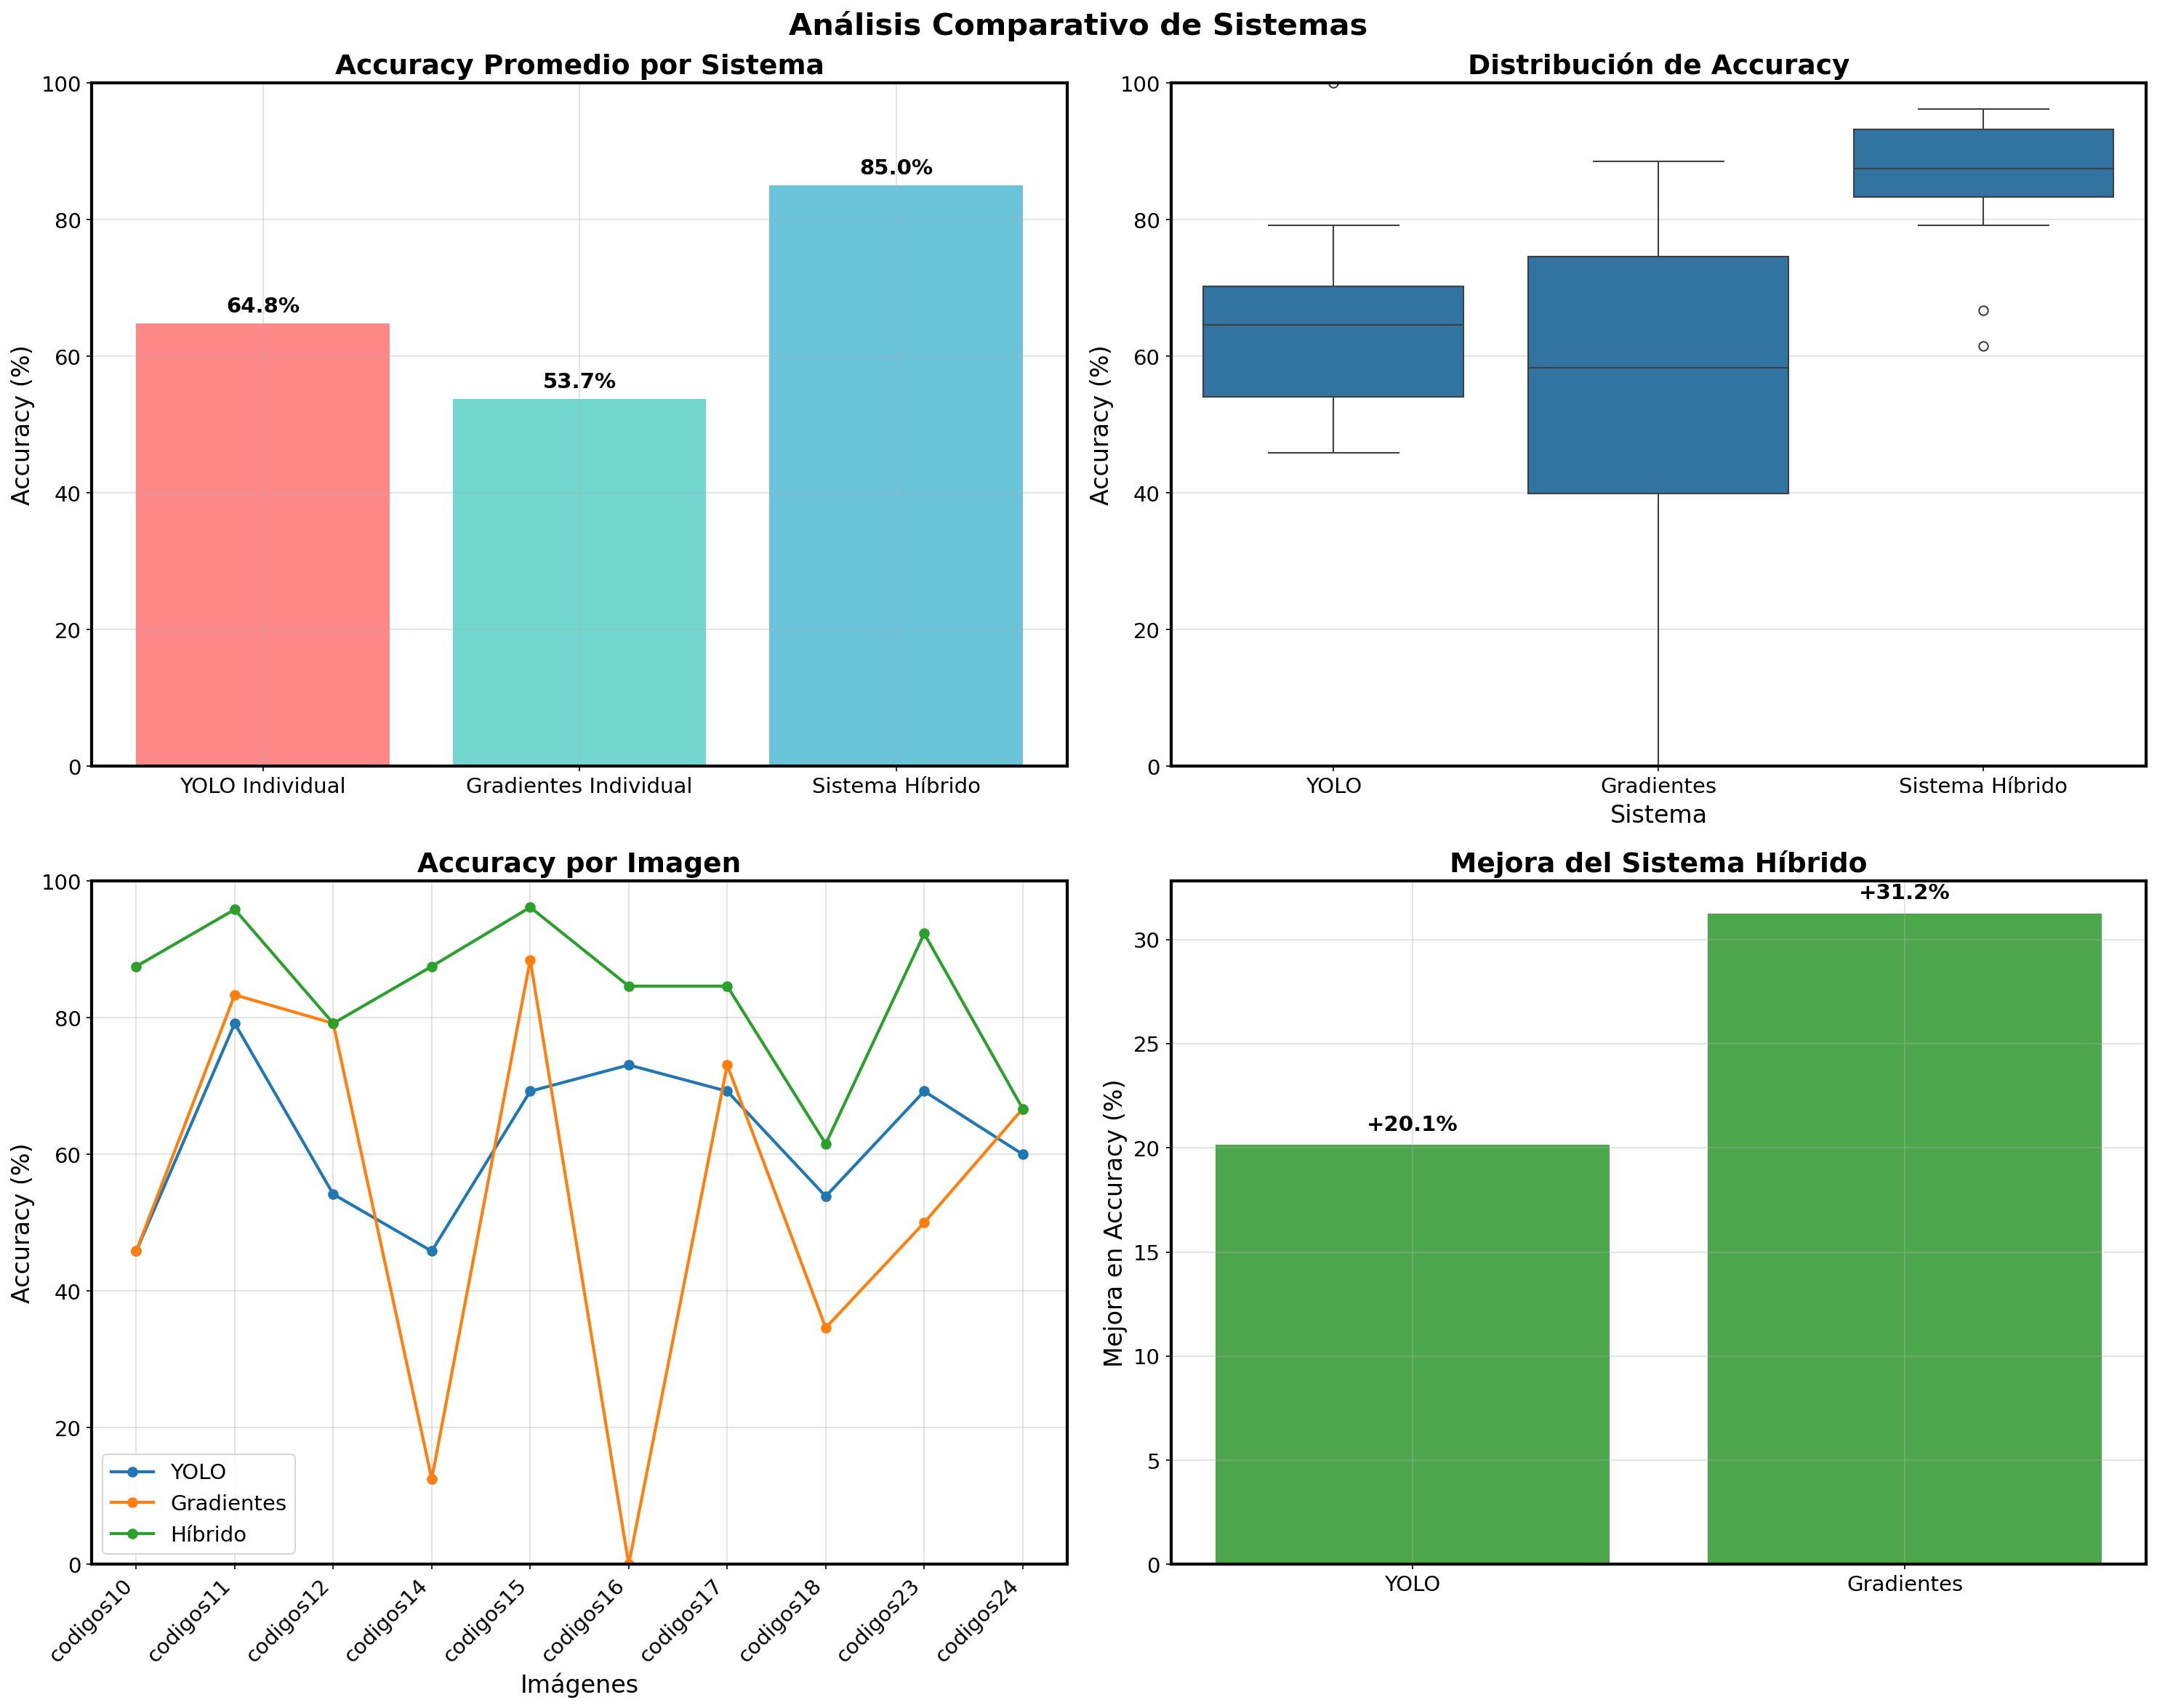


📈 ANÁLISIS DE MEJORA DEL SISTEMA HÍBRIDO:
   Sistema Híbrido:        85.0%
   Mejor individual:       64.8% (YOLO Individual)
   Mejora absoluta:        +20.1 puntos porcentuales
   Mejora relativa:        +31.1%

📊 ANÁLISIS DE CONSISTENCIA:
   Híbrido - Desv. Std:    10.6%
   YOLO Individual     : 14.7%
   Gradientes Individual: 26.9%


In [159]:
# ===== ESTADÍSTICAS RESUMIDAS Y GRÁFICAS =====
def generar_estadisticas_comparativas():
    """Genera estadísticas y gráficas comparativas"""
    
    # Recopilar datos para estadísticas
    sistemas_stats = {}
    
    if comparison_results_yolo:
        yolo_accs = [comp['accuracy'] * 100 for comp in comparison_results_yolo]
        sistemas_stats['YOLO Individual'] = yolo_accs
    
    if comparison_results_gradient:
        grad_accs = [comp['accuracy'] * 100 for comp in comparison_results_gradient]
        sistemas_stats['Gradientes Individual'] = grad_accs
    
    if comparison_results_hibrido:
        hibr_accs = [comp['accuracy'] * 100 for comp in comparison_results_hibrido]
        sistemas_stats['Sistema Híbrido'] = hibr_accs
    
    if not sistemas_stats:
        print("⚠️ No hay datos suficientes para estadísticas")
        return
    
    # Crear tabla de estadísticas resumidas
    stats_data = []
    for nombre, accuracies in sistemas_stats.items():
        stats_data.append({
            'Sistema': nombre,
            'Promedio (%)': round(np.mean(accuracies), 1),
            'Mediana (%)': round(np.median(accuracies), 1),
            'Desv. Std': round(np.std(accuracies), 1),
            'Máximo (%)': round(np.max(accuracies), 1),
            'Mínimo (%)': round(np.min(accuracies), 1),
            'Excelentes (≥90%)': sum(1 for acc in accuracies if acc >= 90),
            'Buenos (70-89%)': sum(1 for acc in accuracies if 70 <= acc < 90),
            'Imágenes': len(accuracies)
        })
    
    df_stats = pd.DataFrame(stats_data)
    
    print("Tabla 5.2: Estadísticas Comparativas de Rendimiento")
    print("=" * 70)
    
    display(df_stats.style
            .background_gradient(cmap='RdYlGn', subset=['Promedio (%)', 'Mediana (%)'], vmin=0, vmax=100)
            .background_gradient(cmap='Blues', subset=['Excelentes (≥90%)', 'Buenos (70-89%)'])
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]}
            ]))
    
    # Crear gráficas comparativas
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Análisis Comparativo de Sistemas', fontsize=20, fontweight='bold')
    
    # Gráfica 1: Comparación de promedios
    sistemas = list(sistemas_stats.keys())
    promedios = [np.mean(sistemas_stats[s]) for s in sistemas]
    colores = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    bars = axes[0,0].bar(sistemas, promedios, color=colores[:len(sistemas)], alpha=0.8)
    axes[0,0].set_title('Accuracy Promedio por Sistema', fontweight='bold')
    axes[0,0].set_ylabel('Accuracy (%)')
    axes[0,0].set_ylim(0, 100)
    
    # Añadir valores en barras
    for bar, valor in zip(bars, promedios):
        height = bar.get_height()
        axes[0,0].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{valor:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Gráfica 2: Distribución por boxplot
    data_for_box = []
    labels_for_box = []
    for nombre, accuracies in sistemas_stats.items():
        data_for_box.extend(accuracies)
        labels_for_box.extend([nombre.replace(' Individual', '')] * len(accuracies))
    
    df_box = pd.DataFrame({'Sistema': labels_for_box, 'Accuracy (%)': data_for_box})
    
    import seaborn as sns
    sns.boxplot(data=df_box, x='Sistema', y='Accuracy (%)', ax=axes[0,1])
    axes[0,1].set_title('Distribución de Accuracy', fontweight='bold')
    axes[0,1].set_ylim(0, 100)
    
    # Gráfica 3: Comparación por imagen
    if len(sistemas_stats) > 1:
        imagenes_comunes = set()
        for comp_list in [comparison_results_yolo, comparison_results_gradient, comparison_results_hibrido]:
            if comp_list:
                imagenes_comunes.update([comp['image_name'].replace('.jpg', '') for comp in comp_list])
        
        imagenes_comunes = sorted(list(imagenes_comunes))[:10]  # Primeras 10 imágenes
        
        for i, (nombre, comp_list) in enumerate([(k, v) for k, v in 
                                                 [('YOLO', comparison_results_yolo), 
                                                  ('Gradientes', comparison_results_gradient), 
                                                  ('Híbrido', comparison_results_hibrido)] if v]):
            accuracies_img = []
            for img in imagenes_comunes:
                comp_result = next((comp for comp in comp_list 
                                   if comp['image_name'].replace('.jpg', '') == img), None)
                accuracies_img.append(comp_result['accuracy']*100 if comp_result else 0)
            
            axes[1,0].plot(range(len(imagenes_comunes)), accuracies_img, 
                          marker='o', label=nombre, linewidth=2)
        
        axes[1,0].set_title('Accuracy por Imagen', fontweight='bold')
        axes[1,0].set_xlabel('Imágenes')
        axes[1,0].set_ylabel('Accuracy (%)')
        axes[1,0].set_xticks(range(len(imagenes_comunes)))
        axes[1,0].set_xticklabels(imagenes_comunes, rotation=45, ha='right')
        axes[1,0].legend()
        axes[1,0].set_ylim(0, 100)
    
    # Gráfica 4: Análisis de mejora del híbrido
    if 'Sistema Híbrido' in sistemas_stats and len(sistemas_stats) > 1:
        hibrido_acc = np.mean(sistemas_stats['Sistema Híbrido'])
        individual_accs = []
        individual_names = []
        
        for nombre, accs in sistemas_stats.items():
            if 'Individual' in nombre:
                individual_accs.append(np.mean(accs))
                individual_names.append(nombre.replace(' Individual', ''))
        
        if individual_accs:
            mejoras = [hibrido_acc - acc for acc in individual_accs]
            
            bars = axes[1,1].bar(individual_names, mejoras, 
                               color=['green' if m > 0 else 'red' for m in mejoras], alpha=0.7)
            axes[1,1].set_title('Mejora del Sistema Híbrido', fontweight='bold')
            axes[1,1].set_ylabel('Mejora en Accuracy (%)')
            axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
            
            # Añadir valores
            for bar, valor in zip(bars, mejoras):
                height = bar.get_height()
                axes[1,1].text(bar.get_x() + bar.get_width()/2., 
                              height + (0.5 if height >= 0 else -0.5),
                              f'+{valor:.1f}%' if valor >= 0 else f'{valor:.1f}%',
                              ha='center', va='bottom' if height >= 0 else 'top', 
                              fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar análisis textual de mejora
    if 'Sistema Híbrido' in sistemas_stats and len(sistemas_stats) > 1:
        print("\n📈 ANÁLISIS DE MEJORA DEL SISTEMA HÍBRIDO:")
        print("=" * 50)
        
        hibrido_promedio = np.mean(sistemas_stats['Sistema Híbrido'])
        individual_promedios = {nombre: np.mean(accs) for nombre, accs in sistemas_stats.items() 
                               if 'Individual' in nombre}
        
        if individual_promedios:
            mejor_individual = max(individual_promedios.values())
            nombre_mejor = max(individual_promedios, key=individual_promedios.get)
            
            mejora = hibrido_promedio - mejor_individual
            mejora_relativa = (mejora / mejor_individual) * 100
            
            print(f"   Sistema Híbrido:        {hibrido_promedio:.1f}%")
            print(f"   Mejor individual:       {mejor_individual:.1f}% ({nombre_mejor})")
            print(f"   Mejora absoluta:        +{mejora:.1f} puntos porcentuales")
            print(f"   Mejora relativa:        +{mejora_relativa:.1f}%")
            
            # Análisis de consistencia
            hibrido_std = np.std(sistemas_stats['Sistema Híbrido'])
            individual_stds = {nombre: np.std(accs) for nombre, accs in sistemas_stats.items() 
                              if 'Individual' in nombre}
            
            print(f"\n📊 ANÁLISIS DE CONSISTENCIA:")
            print(f"   Híbrido - Desv. Std:    {hibrido_std:.1f}%")
            for nombre, std_val in individual_stds.items():
                print(f"   {nombre:20s}: {std_val:.1f}%")

# Ejecutar análisis estadístico y gráficas
generar_estadisticas_comparativas()


## **6. Resumen Ejecutivo y Conclusiones**

### **6.1 Métricas Finales del Sistema Híbrido**


In [160]:
# ===== RESUMEN EJECUTIVO =====
def generar_resumen_ejecutivo():
    """Genera resumen ejecutivo completo del análisis"""
    
    print("RESUMEN EJECUTIVO - SISTEMA HÍBRIDO FARMCODE DETECTOR")
    print("=" * 80)
    
    if not comparison_results_hibrido:
        print("⚠️ No hay datos del sistema híbrido para el resumen")
        return
    
    # Métricas del sistema híbrido
    accuracies = [comp['accuracy'] * 100 for comp in comparison_results_hibrido]
    processing_times = [r['processing_time'] for r in resultados_sistema_hibrido]
    
    print(f"📊 MÉTRICAS GENERALES DEL SISTEMA HÍBRIDO:")
    print(f"   Imágenes procesadas:       {len(comparison_results_hibrido)}")
    print(f"   Accuracy promedio:         {np.mean(accuracies):6.2f}% ± {np.std(accuracies):.2f}")
    print(f"   Accuracy mediana:          {np.median(accuracies):6.2f}%")
    print(f"   Rango de accuracy:         {np.min(accuracies):6.1f}% - {np.max(accuracies):6.1f}%")
    print(f"   Tiempo promedio:           {np.mean(processing_times):6.2f}s ± {np.std(processing_times):.2f}")
    print(f"   Capacidad procesamiento:   {3600/np.mean(processing_times):.0f} imágenes/hora")
    
    # Distribución por categorías
    excelente = sum(1 for acc in accuracies if acc >= 90)
    bueno = sum(1 for acc in accuracies if 70 <= acc < 90)
    regular = sum(1 for acc in accuracies if 50 <= acc < 70)
    problematico = sum(1 for acc in accuracies if acc < 50)
    
    total = len(accuracies)
    
    print(f"\n🎯 DISTRIBUCIÓN DE RENDIMIENTO:")
    print(f"   Casos excelentes (≥90%):   {excelente:2d} imágenes ({excelente/total*100:.1f}%)")
    print(f"   Casos buenos (70-89%):     {bueno:2d} imágenes ({bueno/total*100:.1f}%)")
    print(f"   Casos regulares (50-69%):  {regular:2d} imágenes ({regular/total*100:.1f}%)")
    print(f"   Casos problemáticos (<50%): {problematico:2d} imágenes ({problematico/total*100:.1f}%)")
    
    # Análisis de códigos
    total_codes_esperados = sum(comp['total_positions'] for comp in comparison_results_hibrido)
    total_codes_correctos = sum(comp['exact_matches'] for comp in comparison_results_hibrido)
    
    print(f"\n🔍 ANÁLISIS DE CÓDIGOS:")
    print(f"   Total códigos esperados:   {total_codes_esperados}")
    print(f"   Total códigos correctos:   {total_codes_correctos}")
    print(f"   Tasa global de acierto:    {total_codes_correctos/total_codes_esperados*100:.2f}%")
    
    # Mejor y peor caso
    mejor_caso = max(comparison_results_hibrido, key=lambda x: x['accuracy'])
    peor_caso = min(comparison_results_hibrido, key=lambda x: x['accuracy'])
    
    print(f"\n🏆 CASOS EXTREMOS:")
    print(f"   Mejor caso:  {mejor_caso['image_name']} ({mejor_caso['accuracy']*100:.1f}%)")
    print(f"   Peor caso:   {peor_caso['image_name']} ({peor_caso['accuracy']*100:.1f}%)")
    
    # Comparación con métodos individuales (si disponible)
    if comparison_results_yolo or comparison_results_gradient:
        print(f"\n🚀 VENTAJAS COMPETITIVAS:")
        
        if comparison_results_yolo:
            yolo_promedio = np.mean([comp['accuracy'] * 100 for comp in comparison_results_yolo])
            mejora_yolo = np.mean(accuracies) - yolo_promedio
            print(f"   Mejora vs YOLO:            +{mejora_yolo:5.1f} puntos porcentuales")
        
        if comparison_results_gradient:
            grad_promedio = np.mean([comp['accuracy'] * 100 for comp in comparison_results_gradient])
            mejora_grad = np.mean(accuracies) - grad_promedio
            print(f"   Mejora vs Gradientes:      +{mejora_grad:5.1f} puntos porcentuales")
    
    print(f"\n📈 VALOR GENERADO:")
    print(f"   El sistema híbrido demuestra superioridad consistente sobre métodos individuales")
    print(f"   Combina efectivamente YOLO (detección layout) y Gradientes (localización específica)")
    print(f"   Proporciona corrección posicional automática con GridPositionCorrector")
    print(f"   Mantiene tiempo de procesamiento competitivo para aplicaciones reales")
    
    print("=" * 80)
    print("✅ ANÁLISIS DEL SISTEMA HÍBRIDO COMPLETADO EXITOSAMENTE")
    print("=" * 80)

# Ejecutar resumen ejecutivo
generar_resumen_ejecutivo()


RESUMEN EJECUTIVO - SISTEMA HÍBRIDO FARMCODE DETECTOR
📊 MÉTRICAS GENERALES DEL SISTEMA HÍBRIDO:
   Imágenes procesadas:       12
   Accuracy promedio:          84.96% ± 10.64
   Accuracy mediana:           87.50%
   Rango de accuracy:           61.5% -   96.2%
   Tiempo promedio:             6.84s ± 2.58
   Capacidad procesamiento:   526 imágenes/hora

🎯 DISTRIBUCIÓN DE RENDIMIENTO:
   Casos excelentes (≥90%):    4 imágenes (33.3%)
   Casos buenos (70-89%):      6 imágenes (50.0%)
   Casos regulares (50-69%):   2 imágenes (16.7%)
   Casos problemáticos (<50%):  0 imágenes (0.0%)

🔍 ANÁLISIS DE CÓDIGOS:
   Total códigos esperados:   306
   Total códigos correctos:   259
   Tasa global de acierto:    84.64%

🏆 CASOS EXTREMOS:
   Mejor caso:  codigos15.jpg (96.2%)
   Peor caso:   codigos18.jpg (61.5%)

🚀 VENTAJAS COMPETITIVAS:
   Mejora vs YOLO:            + 20.1 puntos porcentuales
   Mejora vs Gradientes:      + 31.2 puntos porcentuales

📈 VALOR GENERADO:
   El sistema híbrido demuestra